In [1]:
# 解决 OpenMP 库冲突: PyTorch 和 MKL 各自带一份 libiomp5md.dll，重复加载会导致 kernel 崩溃
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'
# 使用 inline 后端，图表直接嵌入 notebook 输出，避免交互式窗口在 VSCode 中不兼容
%matplotlib inline
import torch 
import matplotlib.pyplot as plt

In [2]:
# 生成 -1 到 1 之间的 100 个等间距点，创建输入数据
a=torch.linspace(-1,1,100)
print(a)

# unsqueeze 将一维张量升维为二维 (100,) -> (100,1)，方便后续作为神经网络的输入特征
x=torch.unsqueeze(a,dim=1)
print(x)

tensor([-1.0000, -0.9798, -0.9596, -0.9394, -0.9192, -0.8990, -0.8788, -0.8586,
        -0.8384, -0.8182, -0.7980, -0.7778, -0.7576, -0.7374, -0.7172, -0.6970,
        -0.6768, -0.6566, -0.6364, -0.6162, -0.5960, -0.5758, -0.5556, -0.5354,
        -0.5152, -0.4949, -0.4747, -0.4545, -0.4343, -0.4141, -0.3939, -0.3737,
        -0.3535, -0.3333, -0.3131, -0.2929, -0.2727, -0.2525, -0.2323, -0.2121,
        -0.1919, -0.1717, -0.1515, -0.1313, -0.1111, -0.0909, -0.0707, -0.0505,
        -0.0303, -0.0101,  0.0101,  0.0303,  0.0505,  0.0707,  0.0909,  0.1111,
         0.1313,  0.1515,  0.1717,  0.1919,  0.2121,  0.2323,  0.2525,  0.2727,
         0.2929,  0.3131,  0.3333,  0.3535,  0.3737,  0.3939,  0.4141,  0.4343,
         0.4545,  0.4747,  0.4949,  0.5152,  0.5354,  0.5556,  0.5758,  0.5960,
         0.6162,  0.6364,  0.6566,  0.6768,  0.6970,  0.7172,  0.7374,  0.7576,
         0.7778,  0.7980,  0.8182,  0.8384,  0.8586,  0.8788,  0.8990,  0.9192,
         0.9394,  0.9596,  0.9798,  1.00

torch.Size([100, 1])


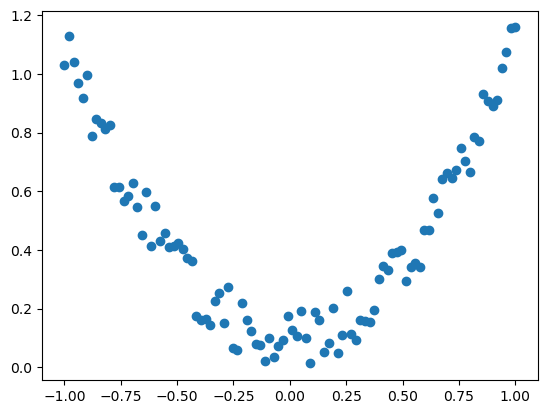

In [3]:
print(x.size())
# 构造目标数据: y = x^2 + 噪声，模拟真实回归问题中的带噪声数据
y = x.pow(2) + 0.2*torch.rand(x.size())                 # noisy y data (tensor), shape=(100, 1)

# 用散点图可视化 x 和 y 的关系，可以看到抛物线趋势加随机扰动
plt.scatter(x.data.numpy(),y.data.numpy())
plt.show()

In [7]:
class Net(torch.nn.Module):
        def __init__(self,n_feature,n_hidden,n_output):
             super(Net,self).__init__()
             self.hidden=torch.nn.Linear(n_feature,n_hidden)
             self.predict=torch.nn.Linear(n_hidden,n_output)

        def forward(self,x):
             x= torch.relu(self.hidden(x))
             x=self.predict(x)
             return x
        # def __init__(self,n_feature,n_hidden,n_output):
        #     super(Net,self).__init__()
        #     # 定义网络层：输入层到隐藏层，使用线性变换
        #     self.hidden=torch.nn.Linear(n_feature,n_hidden)
        #     # 定义网络层：隐藏层到输出层，使用线性变换
        #     self.predict=torch.nn.Linear(n_hidden,n_output)
    
        # def forward(self,x):
        #     # 前向传播：输入 x 经过隐藏层并应用 ReLU 激活函数
        #     x=torch.relu(self.hidden(x))
        #     # 前向传播：隐藏层输出经过输出层得到最终预测结果
        #     x=self.predict(x)
        #     return x
    


net=Net(n_feature=1,n_hidden=10,n_output=1)
print(net)

Net(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (predict): Linear(in_features=10, out_features=1, bias=True)
)


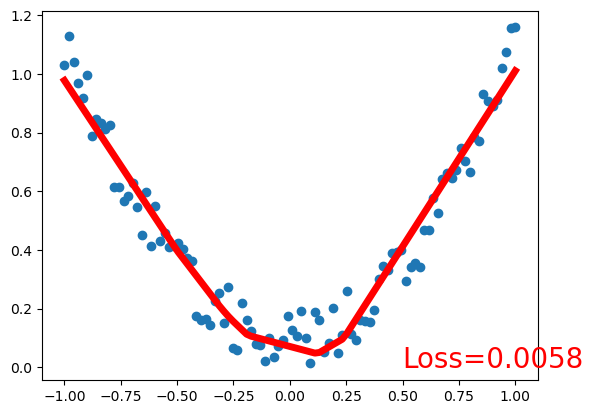

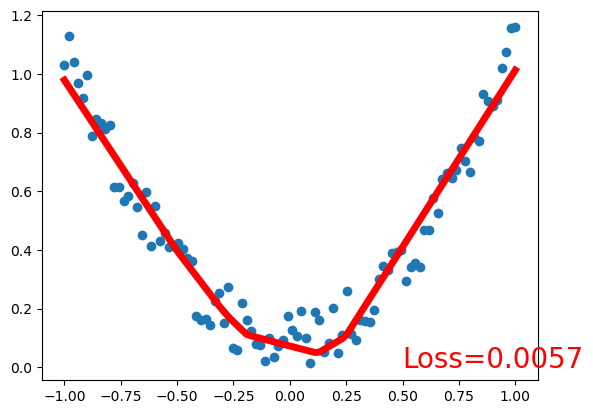

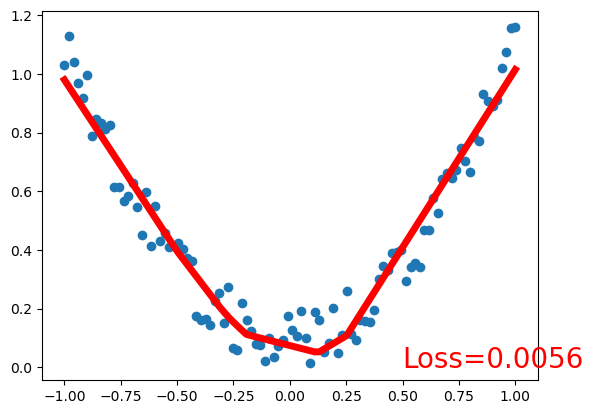

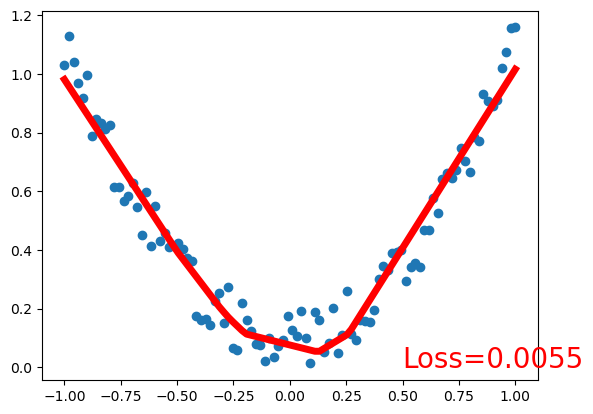

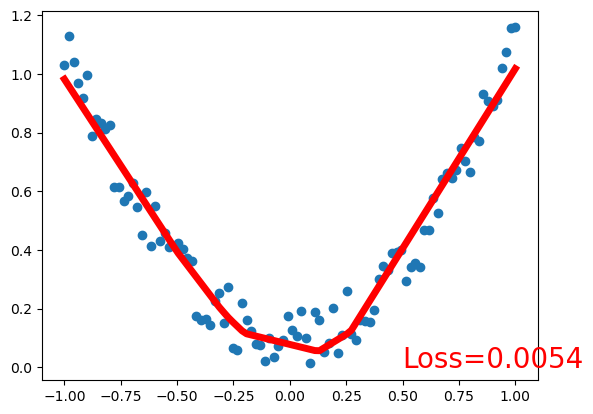

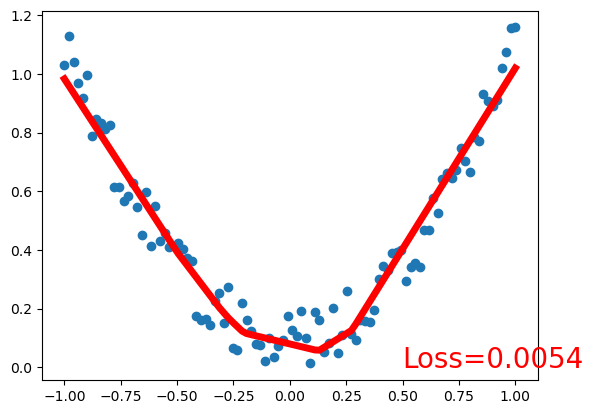

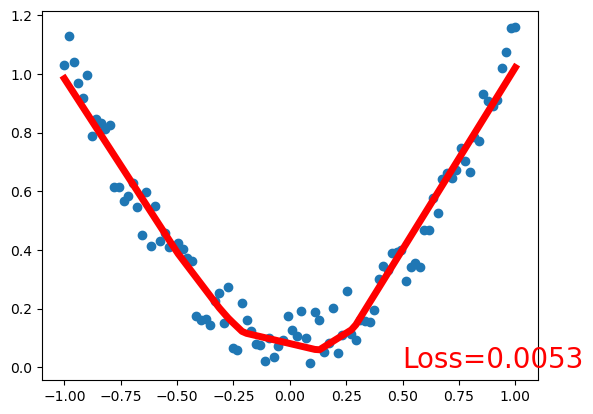

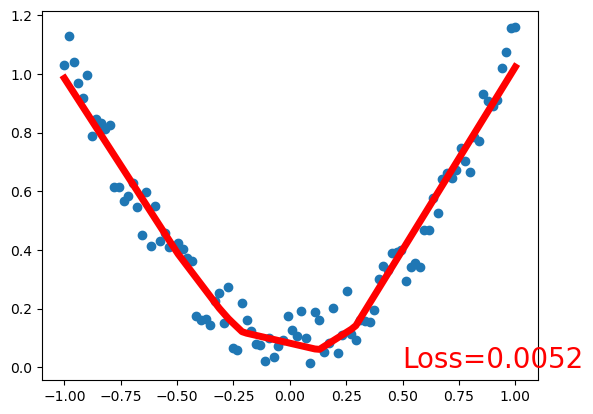

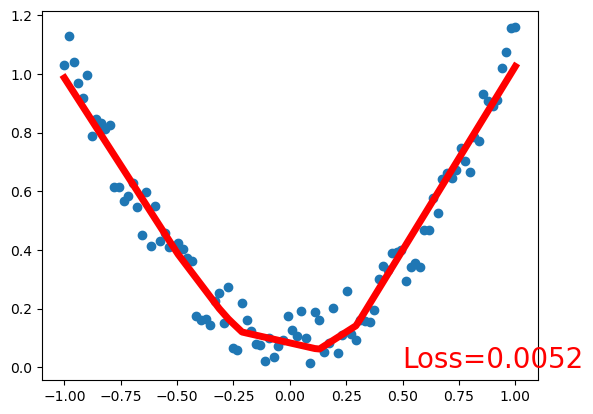

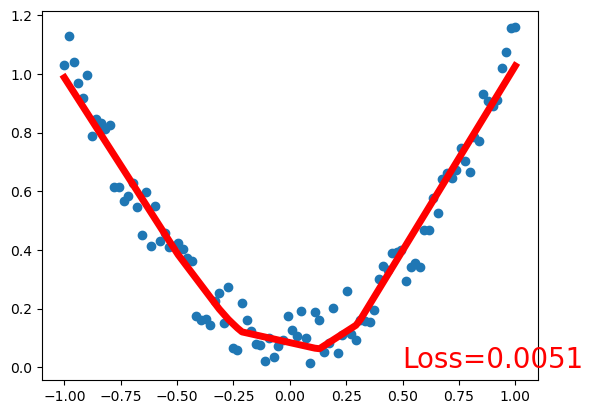

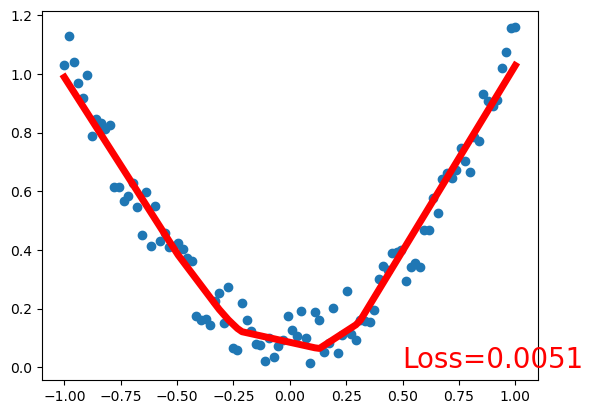

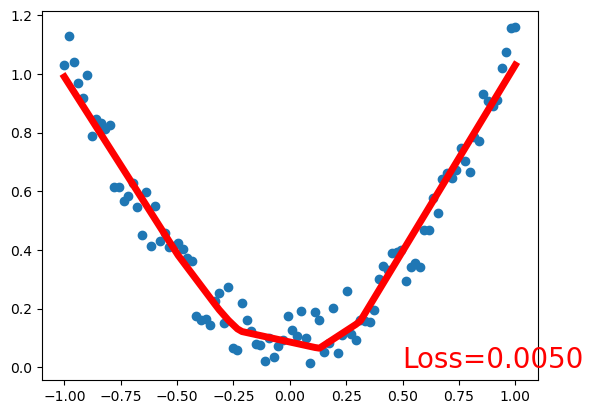

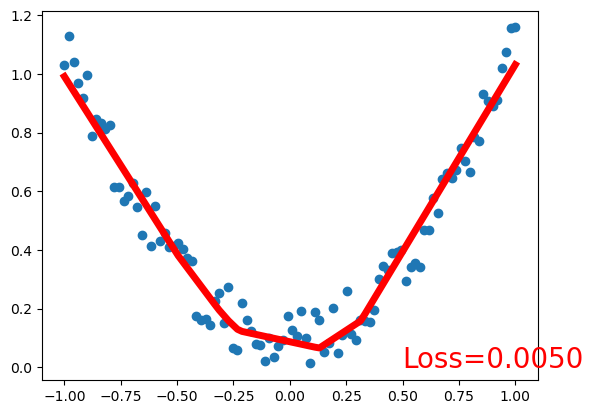

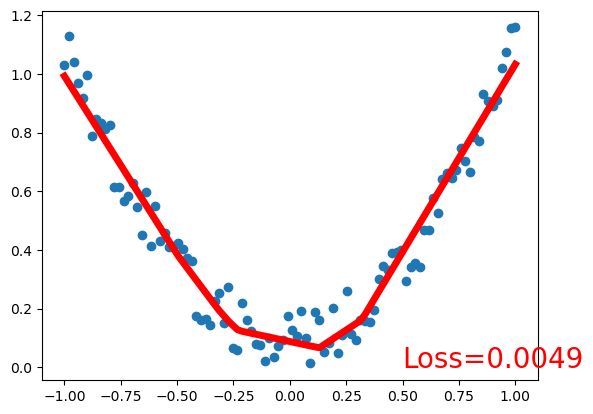

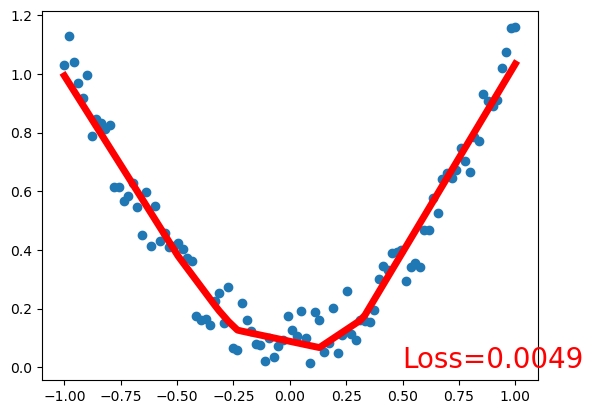

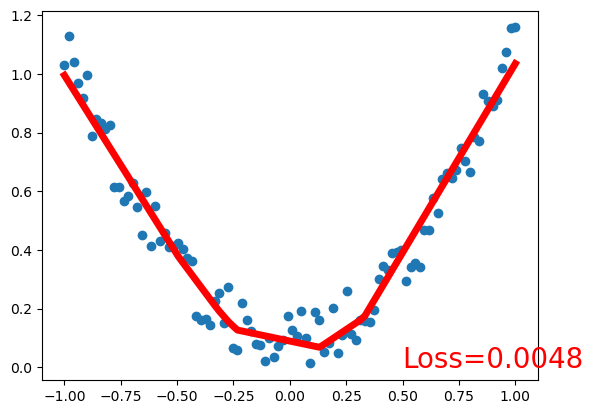

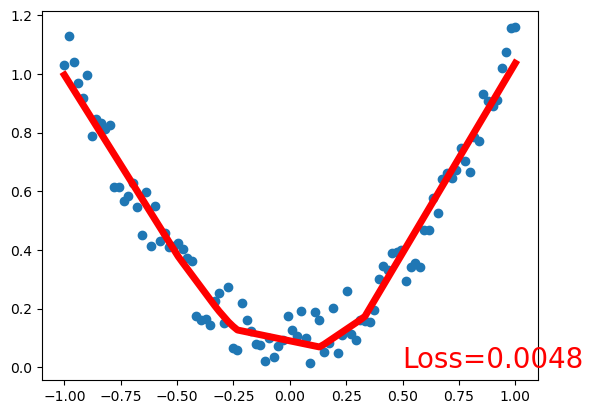

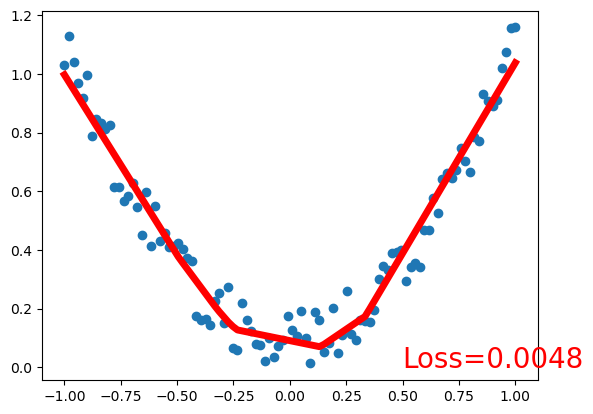

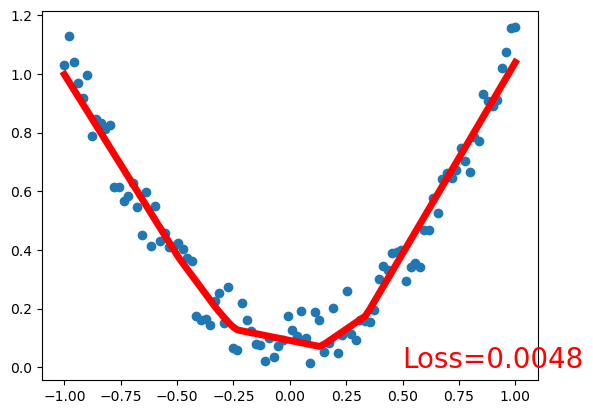

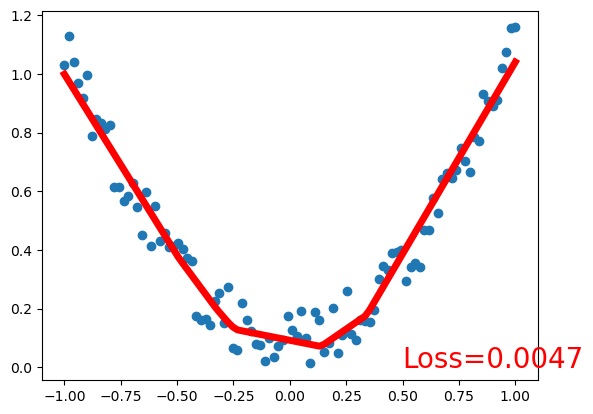

: 

In [ ]:
optimizer=torch.optim.SGD(net.parameters(),lr=0.2)


loss_func=torch.nn.MSELoss()

#plt.ion()
plt.show()
for t in range(100):
    prediction=net(x)
    loss=loss_func(prediction,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t%5==0:
        # plot and show learning process
        plt.cla()
        plt.scatter(x.data.numpy(), y.data.numpy())
        plt.plot(x.data.numpy(), prediction.data.numpy(), 'r-', lw=5)
        plt.text(0.5, 0, 'Loss=%.4f' % loss.data.numpy(), fontdict={'size': 20, 'color':  'red'})
        plt.pause(0.1)
